In [ ]:
# Import Library Packages

import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
import random

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
# Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


Using device: cuda


In [ ]:
# Dataset

dataset = [

    # MEDICATION
    ("Take amoxicillin", "MEDICATION"),
    ("Prescribed amoxicillin", "MEDICATION"),
    ("Start metformin", "MEDICATION"),
    ("Continue lisinopril", "MEDICATION"),
    ("Take ibuprofen", "MEDICATION"),
    ("Prescribed azithromycin", "MEDICATION"),
    ("Start atorvastatin", "MEDICATION"),
    ("Continue aspirin", "MEDICATION"),

    # DOSAGE
    ("Take 500 mg", "DOSAGE"),
    ("Dose is 250 mg", "DOSAGE"),
    ("Give 10 mg", "DOSAGE"),
    ("Take 5 mg", "DOSAGE"),
    ("Dose 100 mcg", "DOSAGE"),
    ("Give 20 mg", "DOSAGE"),
    ("Take 1000 mg", "DOSAGE"),
    ("Dose is 50 mg", "DOSAGE"),

    # FREQUENCY
    ("Take twice daily", "FREQUENCY"),
    ("Take once daily", "FREQUENCY"),
    ("Take three times daily", "FREQUENCY"),
    ("Every six hours", "FREQUENCY"),
    ("Every eight hours", "FREQUENCY"),
    ("Take every morning", "FREQUENCY"),
    ("Take every evening", "FREQUENCY"),
    ("Use twice a day", "FREQUENCY"),

    # ROUTE
    ("Take by mouth", "ROUTE"),
    ("Administer orally", "ROUTE"),
    ("Apply topically", "ROUTE"),
    ("Inject intramuscularly", "ROUTE"),
    ("Inject intravenously", "ROUTE"),
    ("Apply to skin", "ROUTE"),
    ("Use nasal spray", "ROUTE"),
    ("Administer subcutaneously", "ROUTE"),

    # DURATION
    ("For five days", "DURATION"),
    ("For seven days", "DURATION"),
    ("Continue for ten days", "DURATION"),
    ("Use for two weeks", "DURATION"),
    ("Take for three days", "DURATION"),
    ("Continue for one month", "DURATION"),
    ("Use for fourteen days", "DURATION"),
    ("Treatment for five days", "DURATION"),

    # ALLERGY
    ("Patient has a penicillin allergy", "ALLERGY"),
    ("Allergic to aspirin", "ALLERGY"),
    ("No known drug allergies", "ALLERGY"),
    ("Patient reports latex allergy", "ALLERGY"),
    ("Allergy to sulfa drugs", "ALLERGY"),
    ("History of medication allergy", "ALLERGY"),
    ("Patient is allergic to ibuprofen", "ALLERGY"),
    ("Document drug allergies", "ALLERGY"),

    # FOLLOW UP
    ("Follow up in one week", "FOLLOW_UP"),
    ("Return in two weeks", "FOLLOW_UP"),
    ("Follow up with physician", "FOLLOW_UP"),
    ("Return to clinic", "FOLLOW_UP"),
    ("Schedule follow up appointment", "FOLLOW_UP"),
    ("Follow up after treatment", "FOLLOW_UP"),
    ("Return in one month", "FOLLOW_UP"),
    ("Schedule another visit", "FOLLOW_UP"),

    # DIAGNOSIS
    ("Diagnosis is hypertension", "DIAGNOSIS"),
    ("Patient has diabetes", "DIAGNOSIS"),
    ("Diagnosis: pneumonia", "DIAGNOSIS"),
    ("Patient diagnosed with asthma", "DIAGNOSIS"),
    ("Diagnosis is infection", "DIAGNOSIS"),
    ("Patient has high blood pressure", "DIAGNOSIS"),
    ("Diagnosis: bronchitis", "DIAGNOSIS"),
    ("Patient diagnosed with arthritis", "DIAGNOSIS"),
]


print("Total samples:", len(dataset))

Total samples: 64


In [ ]:
# Analyzing Dataset

sentences = [
    sentence.lower().split()
    for sentence, label in dataset
]

word_counter = Counter(
    word
    for sentence in sentences
    for word in sentence
)

word2index = {
    word: index + 1
    for index, word in enumerate(word_counter)
}

# 0 = padding / unknown
word2index["<UNK>"] = 0

index2word = {
    index: word
    for word, index in word2index.items()
}

VOCAB_SIZE = len(word2index)

print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 107


In [ ]:
# Labeling Dataset

labels = sorted(
    list(set(label for sentence, label in dataset))
)

label2index = {
    label: index
    for index, label in enumerate(labels)
}

index2label = {
    index: label
    for label, index in label2index.items()
}

NUM_CLASSES = len(labels)

print("\nClasses:")

for index, label in index2label.items():
    print(index, ":", label)


Classes:
0 : ALLERGY
1 : DIAGNOSIS
2 : DOSAGE
3 : DURATION
4 : FOLLOW_UP
5 : FREQUENCY
6 : MEDICATION
7 : ROUTE


In [ ]:
# Text Encoding

MAX_LENGTH = 8


def encode_sentence(sentence):

    words = sentence.lower().split()

    encoded = [
        word2index.get(word, 0)
        for word in words
    ]

    # Padding
    encoded = encoded[:MAX_LENGTH]

    while len(encoded) < MAX_LENGTH:
        encoded.append(0)

    return encoded


X = []
Y = []

for sentence, label in dataset:

    X.append(
        encode_sentence(sentence)
    )

    Y.append(
        label2index[label]
    )


X = torch.tensor(
    X,
    dtype=torch.long
)

Y = torch.tensor(
    Y,
    dtype=torch.long
)

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)


X shape: torch.Size([64, 8])
Y shape: torch.Size([64])


In [ ]:
# Testing and Training Split

from sklearn.model_selection import train_test_split


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=42,
    stratify=Y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 48
Testing samples : 16


In [ ]:
# Data Loaders

BATCH_SIZE = 8

train_dataset = TensorDataset(
    X_train,
    Y_train
)

test_dataset = TensorDataset(
    X_test,
    Y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# Model

EMBED_DIMENSION = 64
HIDDEN_DIMENSION = 64


class MedicalPrescriptionModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.hidden = nn.Linear(
            embed_dim,
            hidden_dim
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.2)

        self.output = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(self, x):

        # x:
        # (batch_size, sequence_length)

        embeddings = self.embedding(x)

        # Ignore padding when calculating average
        mask = (x != 0).unsqueeze(-1)

        embeddings = embeddings * mask

        word_count = mask.sum(
            dim=1
        ).clamp(min=1)

        sentence_embedding = (
            embeddings.sum(dim=1)
            / word_count
        )

        x = self.hidden(
            sentence_embedding
        )

        x = self.relu(x)

        x = self.dropout(x)

        x = self.output(x)

        return x


model = MedicalPrescriptionModel(
    VOCAB_SIZE,
    EMBED_DIMENSION,
    HIDDEN_DIMENSION,
    NUM_CLASSES
).to(device)

print(model)

MedicalPrescriptionModel(
  (embedding): Embedding(107, 64, padding_idx=0)
  (hidden): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=64, out_features=8, bias=True)
)


In [ ]:
# Training Configuration

EPOCHS = 100

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)

# Training Loss

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

# Accuracy

def calculate_accuracy(
    outputs,
    targets
):

    predictions = torch.argmax(
        outputs,
        dim=1
    )

    correct = (
        predictions == targets
    ).sum().item()

    return correct / len(targets)



In [ ]:
# Training

for epoch in range(EPOCHS)


    model.train()

    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = loss_fn(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_train_loss += (
            loss.item() * len(batch_y)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total_train_correct += (
            predictions == batch_y
        ).sum().item()

        total_train_samples += len(batch_y)


    train_loss = (
        total_train_loss
        / total_train_samples
    )

    train_accuracy = (
        total_train_correct
        / total_train_samples
    )


In [ ]:
# Testing

model.eval()

total_test_loss = 0
total_test_correct = 0
total_test_samples = 0

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        loss = loss_fn(
            outputs,
            batch_y
        )

        total_test_loss += (
            loss.item() * len(batch_y)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total_test_correct += (
            predictions == batch_y
        ).sum().item()

        total_test_samples += len(batch_y)


test_loss = (
    total_test_loss
    / total_test_samples
)

test_accuracy = (
    total_test_correct
    / total_test_samples
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6689
Test Accuracy: 0.8750


In [ ]:
train_losses.append(train_loss)
test_losses.append(test_loss)

train_accuracies.append(train_accuracy)
test_accuracies.append(test_accuracy)

if (epoch + 1) % 10 == 0:
    print(
        f"Epoch {epoch+1:3d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Acc: {test_accuracy:.4f}"
    )

Epoch 100 | Train Loss: 0.0004 | Test Loss: 0.6689 | Train Acc: 1.0000 | Test Acc: 0.8750


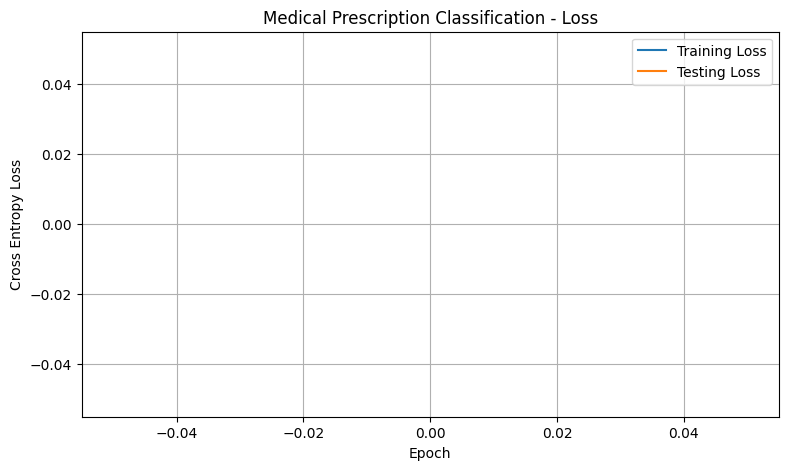

In [ ]:
# Loss Plot

plt.figure(figsize=(9, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    test_losses,
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")

plt.title(
    "Medical Prescription Classification - Loss"
)

plt.legend()

plt.grid(True)

plt.show()

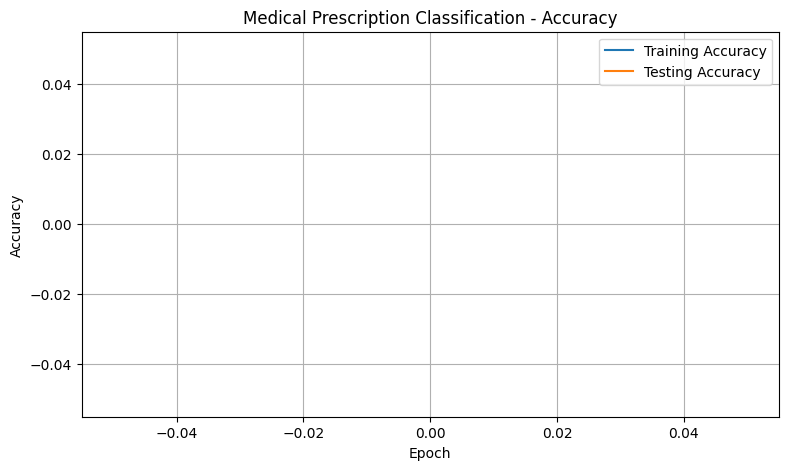

In [ ]:
# Accuracy Plot

plt.figure(figsize=(9, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    test_accuracies,
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Medical Prescription Classification - Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Prediction Function

def predict_prescription(text):

    model.eval()

    encoded = encode_sentence(text)

    x = torch.tensor(
        [encoded],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        output = model(x)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        ).item()

    predicted_label = index2label[
        prediction
    ]

    confidence = probabilities[
        0,
        prediction
    ].item()

    return predicted_label, confidence


In [ ]:
# Test Examples

test_examples = [
    "Take 500 mg",
    "Take twice daily",
    "Take by mouth",
    "For seven days",
    "Patient has a penicillin allergy",
    "Follow up in one week",
    "Diagnosis is hypertension",
    "Take amoxicillin"
]


for text in test_examples:

    label, confidence = (
        predict_prescription(text)
    )

    print(
        f"{text:45s} -> "
        f"{label:12s} "
        f"({confidence:.2%})"
    )

Take 500 mg                                   -> DOSAGE       (100.00%)
Take twice daily                              -> FREQUENCY    (100.00%)
Take by mouth                                 -> MEDICATION   (58.45%)
For seven days                                -> DURATION     (100.00%)
Patient has a penicillin allergy              -> ALLERGY      (99.98%)
Follow up in one week                         -> FOLLOW_UP    (100.00%)
Diagnosis is hypertension                     -> DIAGNOSIS    (99.98%)
Take amoxicillin                              -> MEDICATION   (99.12%)
